In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# settings
RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [5]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Original shape:", df.shape)
display(df.head())
print(df.info())

Original shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
print("Missing values by column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values by column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling   

In [7]:
# Convert TotalCharges to numeric (invalid -> NaN)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop customerID
df = df.drop("customerID", axis=1)

print("Shape after cleaning:", df.shape)
print(df.dtypes)

Shape after cleaning: (7043, 20)
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


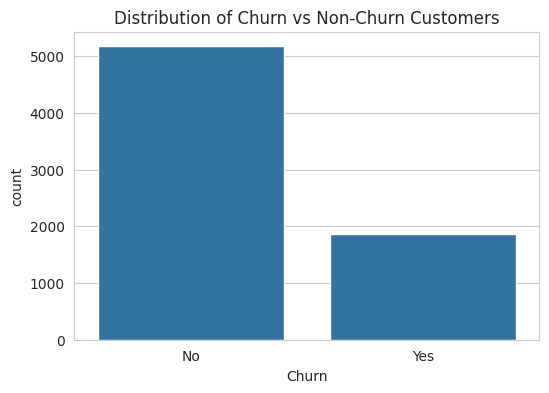

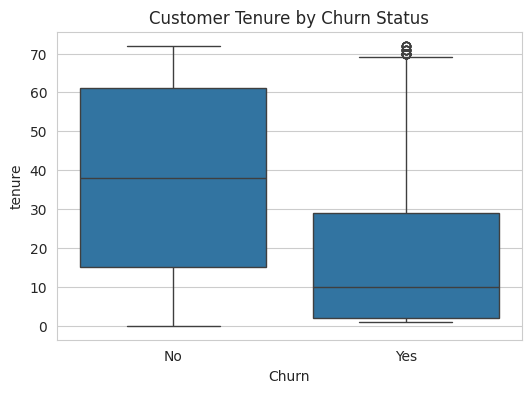

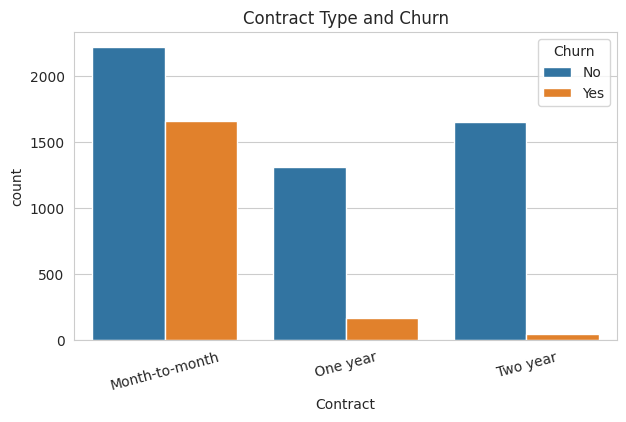

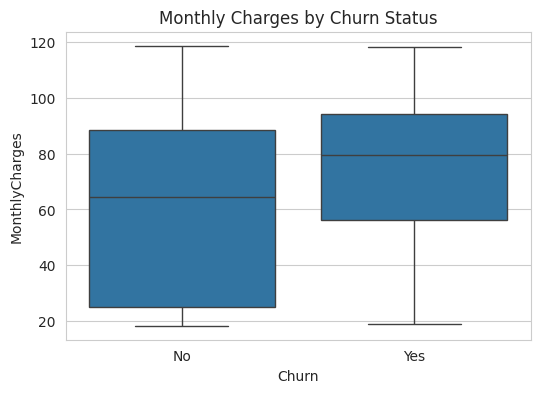

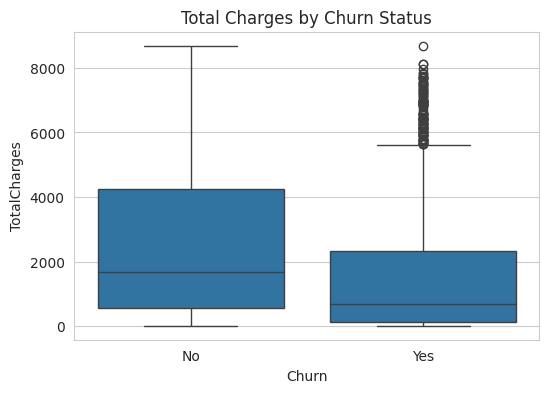

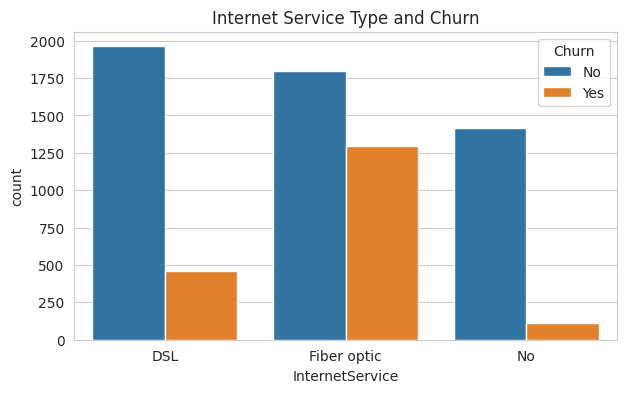

In [8]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Distribution of Churn vs Non-Churn Customers")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Customer Tenure by Churn Status")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract Type and Churn")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="TotalCharges")
plt.title("Total Charges by Churn Status")
plt.show()

plt.figure(figsize=(7,4))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Internet Service Type and Churn")
plt.show()

In [ ]:
####### ML START HERE !!!
# y
y = df["Churn"].map({"Yes": 1, "No": 0})

# X (keep raw, no get_dummies here)
X = df.drop("Churn", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

# 80/10/10 split with stratify
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("\nTrain shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

X shape: (7043, 19)
y shape: (7043,)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65



Train shape: (5634, 19) (5634,)
Validation shape: (704, 19) (704,)
Test shape: (705, 19) (705,)


In [10]:
# detect column types from TRAIN only
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

base_models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1.0, 10.0],
        "model__class_weight": [None, "balanced"],
        "model__solver": ["lbfgs"],
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 10, 30],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"],
    },
    "Random Forest": {
        "model__n_estimators": [200, 500],
        "model__max_depth": [5, 10, None],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"],
    }
}

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


/tmp/ipykernel_6299/2601250612.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object", "bool", "category"]).columns.tolist()


In [12]:
def compute_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

def iter_param_combinations(grid_dict):
    keys = list(grid_dict.keys())
    vals = [grid_dict[k] for k in keys]
    for combo in product(*vals):
        yield dict(zip(keys, combo))

# Selection rule (必须明确):
# maximize Val F1; tie -> Val Recall; tie -> Val Accuracy
def is_better(a, b):
    if b is None:
        return True
    if a["Val_F1"] != b["Val_F1"]:
        return a["Val_F1"] > b["Val_F1"]
    if a["Val_Recall"] != b["Val_Recall"]:
        return a["Val_Recall"] > b["Val_Recall"]
    return a["Val_Accuracy"] > b["Val_Accuracy"]

tuning_rows = []
best_choice = None

In [13]:
# ---- hyperparameter tuning on VALIDATION ----
for model_name, base_model in base_models.items():
    print("\n" + "="*70)
    print("TUNING:", model_name)
    print("="*70)

    for params in iter_param_combinations(param_grids[model_name]):
        pipe = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", base_model),
        ])
        pipe.set_params(**params)

        # fit ONLY on train
        pipe.fit(X_train, y_train)

        # metrics on train (check overfitting)
        pred_train = pipe.predict(X_train)
        m_train = compute_metrics(y_train, pred_train)

        # metrics on val (choose model/params)
        pred_val = pipe.predict(X_val)
        m_val = compute_metrics(y_val, pred_val)

        row = {
            "Model": model_name,
            **{k.replace("model__", ""): v for k, v in params.items()},
            "Train_Accuracy": m_train["Accuracy"],
            "Train_Precision": m_train["Precision"],
            "Train_Recall": m_train["Recall"],
            "Train_F1": m_train["F1"],
            "Val_Accuracy": m_val["Accuracy"],
            "Val_Precision": m_val["Precision"],
            "Val_Recall": m_val["Recall"],
            "Val_F1": m_val["F1"],
        }
        tuning_rows.append(row)

        candidate = {
            "Model": model_name,
            "Params": params,
            "Val_Accuracy": m_val["Accuracy"],
            "Val_Precision": m_val["Precision"],
            "Val_Recall": m_val["Recall"],
            "Val_F1": m_val["F1"],
        }

        if is_better(candidate, best_choice):
            best_choice = candidate

tuning_df = pd.DataFrame(tuning_rows)

print("\nTop 20 on VALIDATION (Val_F1, Val_Recall, Val_Accuracy):")
display(tuning_df.sort_values(["Val_F1", "Val_Recall", "Val_Accuracy"], ascending=False).head(20))

print("\nBEST (based on validation):")
print("Model:", best_choice["Model"])
print("Params:", best_choice["Params"])
print(f"Val Accuracy={best_choice['Val_Accuracy']:.4f}  "
      f"Val Precision={best_choice['Val_Precision']:.4f}  "
      f"Val Recall={best_choice['Val_Recall']:.4f}  "
      f"Val F1={best_choice['Val_F1']:.4f}")



TUNING: Logistic Regression

TUNING: Decision Tree

TUNING: Random Forest

Top 20 on VALIDATION (Val_F1, Val_Recall, Val_Accuracy):


,Model,C,class_weight,solver,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Accuracy,Val_Precision,Val_Recall,Val_F1,max_depth,min_samples_split,min_samples_leaf,n_estimators
103,Random Forest,NaN,balanced,NaN,0.864927,0.683684,0.913712,0.782136,0.769886,0.549407,0.743316,0.631818,10.0,NaN,1.0,500.0
111,Random Forest,NaN,balanced,NaN,0.845758,0.657762,0.872910,0.750216,0.767045,0.544747,0.748663,0.630631,NaN,NaN,5.0,500.0
24,Decision Tree,NaN,NaN,NaN,0.803869,0.652106,0.559197,0.602089,0.808239,0.646067,0.614973,0.630137,5.0,2.0,1.0,NaN
26,Decision Tree,NaN,NaN,NaN,0.803159,0.651017,0.556522,0.600072,0.808239,0.646067,0.614973,0.630137,5.0,2.0,5.0,NaN
28,Decision Tree,NaN,NaN,NaN,0.802804,0.649300,0.558528,0.600503,0.808239,0.646067,0.614973,0.630137,5.0,2.0,10.0,NaN
30,Decision Tree,NaN,NaN,NaN,0.803692,0.651362,0.559866,0.602158,0.808239,0.646067,0.614973,0.630137,5.0,10.0,1.0,NaN
32,Decision Tree,NaN,NaN,NaN,0.803159,0.651017,0.556522,0.600072,0.808239,0.646067,0.614973,0.630137,5.0,10.0,5.0,NaN
34,Decision Tree,NaN,NaN,NaN,0.802804,0.649300,0.558528,0.600503,0.808239,0.646067,0.614973,0.630137,5.0,10.0,10.0,NaN
36,Decision Tree,NaN,NaN,NaN,0.803692,0.651362,0.559866,0.602158,0.808239,0.646067,0.614973,0.630137,5.0,30.0,1.0,NaN
38,Decision Tree,NaN,NaN,NaN,0.803159,0.651017,0.556522,0.600072,0.808239,0.646067,0.614973,0.630137,5.0,30.0,5.0,NaN



BEST (based on validation):
Model: Random Forest
Params: {'model__n_estimators': 500, 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__class_weight': 'balanced'}
Val Accuracy=0.7699  Val Precision=0.5494  Val Recall=0.7433  Val F1=0.6318


In [18]:
# ======= Clean PPT table: only 4 metrics (train & val) for each model =======

def pick_best_row_for_one_model(df_one_model):
    # same selection rule as before: Val_F1 -> Val_Recall -> Val_Accuracy
    return df_one_model.sort_values(
        ["Val_F1", "Val_Recall", "Val_Accuracy"],
        ascending=False
    ).head(1)

best_rows = []
for model_name in tuning_df["Model"].unique():
    one = tuning_df[tuning_df["Model"] == model_name].copy()
    best_rows.append(pick_best_row_for_one_model(one))

best_by_model_df = pd.concat(best_rows, ignore_index=True)

# Keep ONLY metrics columns (no hyperparameters)
metrics_only_df = best_by_model_df[[
    "Model",
    "Train_Accuracy", "Train_Precision", "Train_Recall", "Train_F1",
    "Val_Accuracy", "Val_Precision", "Val_Recall", "Val_F1"
]].copy()

# Make it prettier for screenshots
metrics_only_df = metrics_only_df.set_index("Model").round(4)

print("Best (per model) metrics on Train vs Validation:")
display(metrics_only_df)

Best (per model) metrics on Train vs Validation:


,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
Model,,,,,,,,
Logistic Regression,0.8060,0.6616,0.5505,0.6009,0.8125,0.6687,0.5829,0.6229
Decision Tree,0.8039,0.6521,0.5592,0.6021,0.8082,0.6461,0.6150,0.6301
Random Forest,0.8649,0.6837,0.9137,0.7821,0.7699,0.5494,0.7433,0.6318


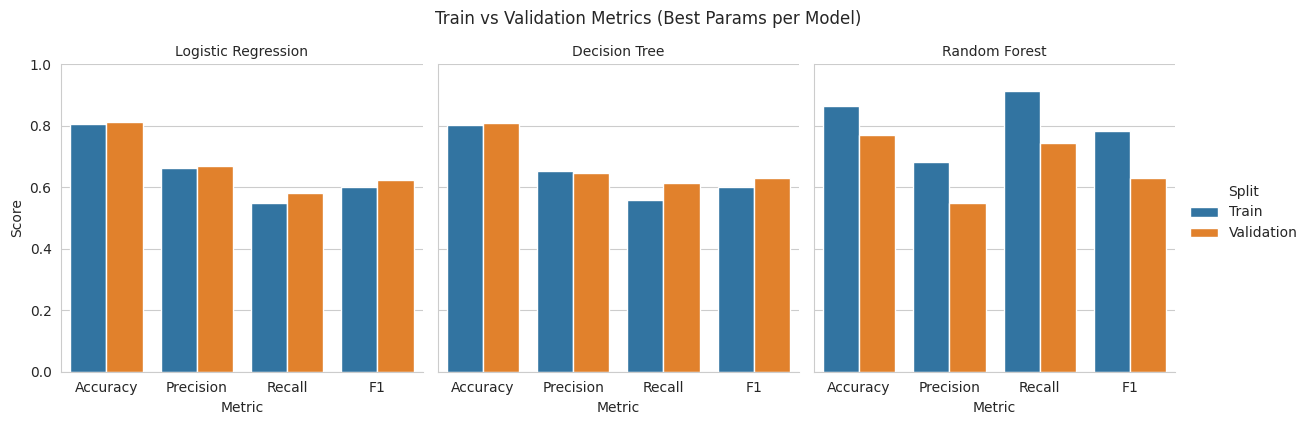

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# metrics_only_df index = Model, columns include Train_* and Val_*
plot_df = metrics_only_df.reset_index()

# 转成长表方便画图
long_rows = []
for _, r in plot_df.iterrows():
    model = r["Model"]
    for metric in ["Accuracy", "Precision", "Recall", "F1"]:
        long_rows.append({"Model": model, "Split": "Train", "Metric": metric, "Score": r[f"Train_{metric}"]})
        long_rows.append({"Model": model, "Split": "Validation", "Metric": metric, "Score": r[f"Val_{metric}"]})

long_df = pd.DataFrame(long_rows)

g = sns.catplot(
    data=long_df,
    x="Metric", y="Score",
    hue="Split",
    col="Model",
    kind="bar",
    col_wrap=3,
    height=4,
    aspect=1
)
g.set(ylim=(0, 1))
g.set_titles("{col_name}")
g.fig.suptitle("Train vs Validation Metrics (Best Params per Model)", y=1.05)
plt.show()

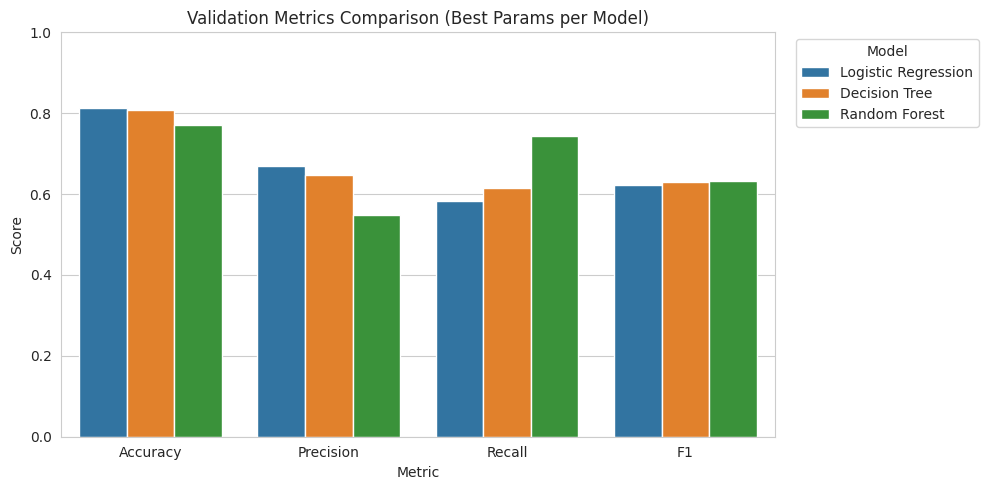

In [ ]:
# ======= (for PPT use ) 三个模型在 Validation 上四指标对比图 =======
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = best_by_model_df[[
    "Model", "Val_Accuracy", "Val_Precision", "Val_Recall", "Val_F1"
]].copy()

plot_long = plot_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# make the index names look more pretty lolllllll
plot_long["Metric"] = plot_long["Metric"].str.replace("Val_", "", regex=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1)
plt.title("Validation Metrics Comparison (Best Params per Model)")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
# ---- final evaluation on TEST (USED ONCE) ----
final_model_name = best_choice["Model"]
final_base_model = base_models[final_model_name]

final_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", final_base_model),
])
final_pipe.set_params(**best_choice["Params"])

# Scheme A: fit ONLY on train
final_pipe.fit(X_train, y_train)

pred_test = final_pipe.predict(X_test)

acc = accuracy_score(y_test, pred_test)
pre = precision_score(y_test, pred_test, zero_division=0)
rec = recall_score(y_test, pred_test, zero_division=0)
f1 = f1_score(y_test, pred_test, zero_division=0)

print("\n" + "="*70)
print("FINAL TEST EVALUATION (test used once)")
print("="*70)
print("Chosen model:", final_model_name)
print("Chosen params:", best_choice["Params"])
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")

print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred_test))
print("\nClassification Report:\n")
print(classification_report(y_test, pred_test, zero_division=0))

############################## conclusion：
#Chosen model was **Random Forest** (500 trees, max depth 10, 
# `class_weight='balanced'`). 
# On the held‑out **test set (n=705)** 
# it achieved **Accuracy = 0.767**, 
# **Precision = 0.550**, **Recall = 0.679**, 
# and **F1 = 0.608**, meaning it correctly identified about **68% of churn customers** 
# while maintaining an overall accuracy of about **77%**.


FINAL TEST EVALUATION (test used once)
Chosen model: Random Forest
Chosen params: {'model__n_estimators': 500, 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__class_weight': 'balanced'}
Accuracy:  0.7674
Precision: 0.5498
Recall:    0.6791
F1:        0.6077

Confusion Matrix:
 [[414 104]
 [ 60 127]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       518
           1       0.55      0.68      0.61       187

    accuracy                           0.77       705
   macro avg       0.71      0.74      0.72       705
weighted avg       0.79      0.77      0.77       705



In [21]:
best_by_model_df.to_csv("best_metrics_by_model.csv", index=False)

Top 10 Features - Random Forest


,Feature,Importance
1,tenure,0.122006
36,Contract_Month-to-month,0.112716
3,TotalCharges,0.107718
2,MonthlyCharges,0.078584
38,Contract_Two year,0.059611
18,OnlineSecurity_No,0.055352
27,TechSupport_No,0.050377
16,InternetService_Fiber optic,0.043736
43,PaymentMethod_Electronic check,0.032351
37,Contract_One year,0.019390


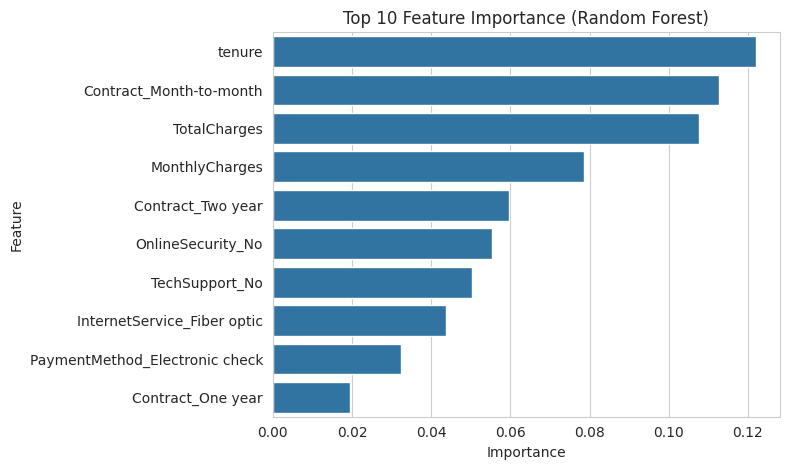

In [ ]:

# 1) 拿到 one-hot 后的全部特征名
def get_feature_names(preprocess, numeric_features, categorical_features):
    num_names = list(numeric_features)

    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_names = list(ohe.get_feature_names_out(categorical_features))

    return num_names + cat_names

# 2) calsulate the " importance "
preprocess = final_pipe.named_steps["preprocess"]
model = final_pipe.named_steps["model"]

feature_names = get_feature_names(preprocess, numeric_features, categorical_features)

if hasattr(model, "coef_"):  # Logistic Regression
    coef = model.coef_.ravel()
    importance = np.abs(coef)

    top_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance,
        "Direction": np.where(coef >= 0, "Increase churn", "Decrease churn")
    }).sort_values("Importance", ascending=False).head(10)

elif hasattr(model, "feature_importances_"):  # Decision Tree / Random Forest
    importance = model.feature_importances_

    top_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values("Importance", ascending=False).head(10)

else:
    raise ValueError("Model does not support feature importance (no coef_ or feature_importances_).")

print(f"Top 10 Features - {final_model_name}")
display(top_df)

# 3) plot
plt.figure(figsize=(8, 4.8))
sns.barplot(data=top_df, x="Importance", y="Feature", orient="h")
plt.title(f"Top 10 Feature Importance ({final_model_name})")
plt.tight_layout()
plt.show()